In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.insert(0, str(PROJECT_ROOT))

PROCESSED   = PROJECT_ROOT / "data" / "processed"
MATCHED_DIR = PROCESSED / "matched"

SEPHORA_COLOR = "#E91E63"
ULTA_COLOR    = "#9C27B0"
PARITY_COLOR  = "#4CAF50"
NEUTRAL       = "#90A4AE"

In [2]:
matched     = pd.read_csv(MATCHED_DIR /"matched_pairs.csv",
                           dtype={"sephora_product_id": str,
                                  "ulta_product_id":    str})
sephora_df  = pd.read_csv(PROCESSED / "Sephora" /"sephora_segmentation.csv",
                           dtype={"product_id": str})
ulta_df     = pd.read_csv(PROCESSED / "Ulta" / "ulta_segmentation.csv",
                           dtype={"product_id": str})

# Pull sentiment columns onto matched pairs
SENT_COLS = ["avg_sentiment", "pct_positive", "pct_negative", "avg_rating",
             "rating_std", "pct_5_star", "pct_1_star"]

cross = (
    matched
    .merge(
        sephora_df[["product_id"] + [c for c in SENT_COLS if c in sephora_df.columns]]
            .add_suffix("_s")
            .rename(columns={"product_id_s": "sephora_product_id"}),
        on="sephora_product_id", how="inner"
    )
    .merge(
        ulta_df[["product_id", "category"] + [c for c in SENT_COLS if c in ulta_df.columns]]
            .add_suffix("_u")
            .rename(columns={"product_id_u": "ulta_product_id",
                              "category_u":   "ulta_category"}),
        on="ulta_product_id", how="inner"
    )
)

# Numeric coercion
for col in ["sephora_price", "ulta_price", "sephora_rating", "ulta_rating"]:
    cross[col] = pd.to_numeric(cross[col], errors="coerce")

cross = cross.dropna(subset=["sephora_price", "ulta_price"])

cross["price_delta"]    = cross["sephora_price"]  - cross["ulta_price"]
cross["price_delta_pct"]= cross["price_delta"]    / cross["ulta_price"] * 100
cross["price_parity"]   = cross["price_delta"].abs() <= 1.00

# Rating / sentiment deltas (from segmentation cols, not matched_pairs cols)
if "avg_rating_s" in cross.columns and "avg_rating_u" in cross.columns:
    cross["rating_delta"]   = (pd.to_numeric(cross["avg_rating_s"], errors="coerce") -
                                pd.to_numeric(cross["avg_rating_u"], errors="coerce"))
if "avg_sentiment_s" in cross.columns and "avg_sentiment_u" in cross.columns:
    cross["sentiment_delta"]= (pd.to_numeric(cross["avg_sentiment_s"], errors="coerce") -
                                pd.to_numeric(cross["avg_sentiment_u"], errors="coerce"))

# Perceived value efficiency: sentiment per dollar, rating per dollar
for platform, price_col, rating_col, sent_col in [
    ("sephora", "sephora_price", "sephora_rating", "avg_rating_s"),
    ("ulta",    "ulta_price",    "ulta_rating",    "avg_rating_u"),
]:
    cross[f"{platform}_rating_per_dollar"]   = (
        pd.to_numeric(cross[rating_col], errors="coerce") /
        cross[f"{platform}_price"].replace(0, np.nan)
    )
    if f"avg_sentiment_s" in cross.columns:
        sent = "avg_sentiment_s" if platform == "sephora" else "avg_sentiment_u"
        cross[f"{platform}_sentiment_per_dollar"] = (
            pd.to_numeric(cross[sent], errors="coerce") /
            cross[f"{platform}_price"].replace(0, np.nan)
        )

print(f"Matched pairs with price data: {len(cross):,}")
print(f"\nPrice parity (|Δ| ≤ $1) : {cross['price_parity'].sum():,}  "
      f"({cross['price_parity'].mean():.1%})")
print(f"Sephora higher (>$1)     : {(cross['price_delta'] > 1).sum():,}  "
      f"({(cross['price_delta'] > 1).mean():.1%})")
print(f"Ulta higher (>$1)        : {(cross['price_delta'] < -1).sum():,}  "
      f"({(cross['price_delta'] < -1).mean():.1%})")
print(f"\nPrice delta  mean   : ${cross['price_delta'].mean():+.2f}")
print(f"Price delta  median : ${cross['price_delta'].median():+.2f}")
print(f"Price delta  std    : ${cross['price_delta'].std():.2f}")

Matched pairs with price data: 379

Price parity (|Δ| ≤ $1) : 257  (67.8%)
Sephora higher (>$1)     : 57  (15.0%)
Ulta higher (>$1)        : 65  (17.2%)

Price delta  mean   : $+0.60
Price delta  median : $+0.00
Price delta  std    : $33.93


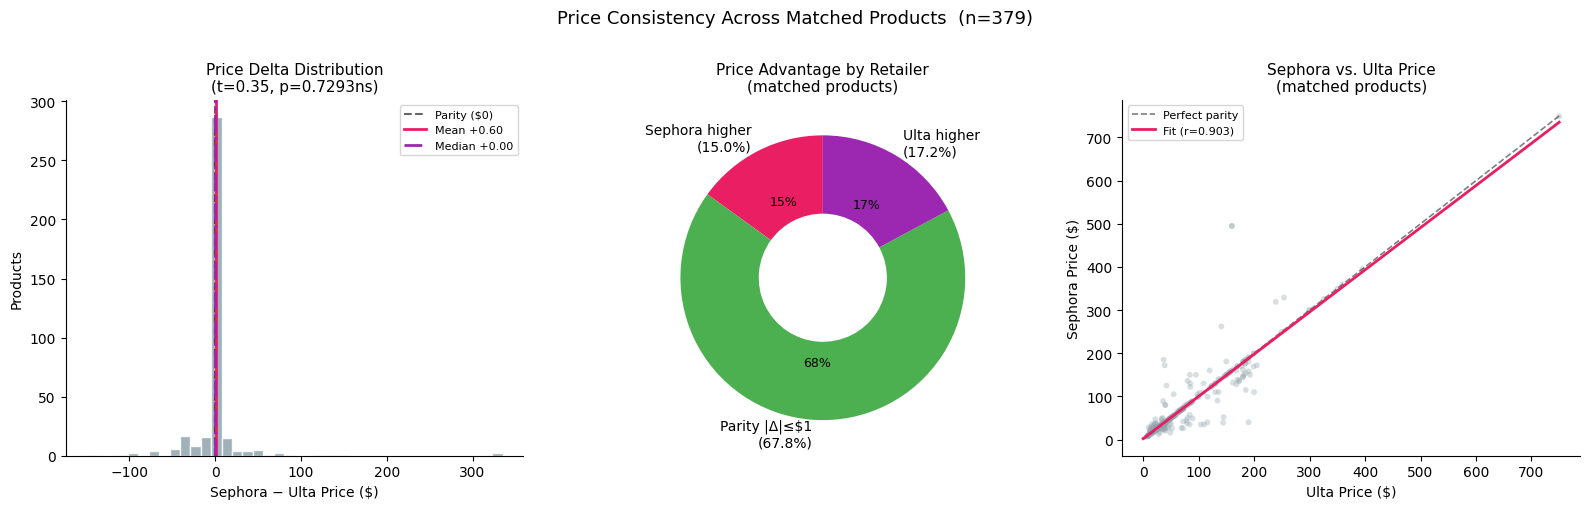

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: histogram of price deltas
arr = cross["price_delta"].dropna().values
axes[0].hist(arr, bins=40, color=NEUTRAL, edgecolor="white", alpha=0.85)
axes[0].axvline(0,            color="black",        lw=1.5, ls="--", alpha=0.6,
                label="Parity ($0)")
axes[0].axvline(arr.mean(),   color=SEPHORA_COLOR,  lw=2,   ls="-",
                label=f"Mean {arr.mean():+.2f}")
axes[0].axvline(np.median(arr), color=ULTA_COLOR,   lw=2,   ls="-.",
                label=f"Median {np.median(arr):+.2f}")
t, p = stats.ttest_1samp(arr[~np.isnan(arr)], 0)
sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
axes[0].set_title(f"Price Delta Distribution\n(t={t:.2f}, p={p:.4f}{sig})",
                  fontsize=11)
axes[0].set_xlabel("Sephora − Ulta Price ($)", fontsize=10)
axes[0].set_ylabel("Products", fontsize=10)
axes[0].legend(fontsize=8)
axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: donut — price advantage breakdown
sizes  = [(cross["price_delta"] > 1).sum(),
          cross["price_parity"].sum(),
          (cross["price_delta"] < -1).sum()]
labels = [f"Sephora higher\n({sizes[0]/len(cross):.1%})",
          f"Parity |Δ|≤$1\n({sizes[1]/len(cross):.1%})",
          f"Ulta higher\n({sizes[2]/len(cross):.1%})"]
wedges, _, autotexts = axes[1].pie(
    sizes, labels=labels, autopct="%1.0f%%", startangle=90,
    colors=[SEPHORA_COLOR, PARITY_COLOR, ULTA_COLOR],
    wedgeprops=dict(width=0.55),
)
for at in autotexts:
    at.set_fontsize(9)
axes[1].set_title("Price Advantage by Retailer\n(matched products)", fontsize=11)

# Panel 3: scatter — Sephora price vs Ulta price
max_p = max(cross["sephora_price"].max(), cross["ulta_price"].max())
axes[2].scatter(cross["ulta_price"], cross["sephora_price"],
                alpha=0.35, s=18, color=NEUTRAL, edgecolors="none")
axes[2].plot([0, max_p], [0, max_p], color="black", lw=1.2, ls="--",
             alpha=0.5, label="Perfect parity")
# Regression line
mask = cross[["ulta_price", "sephora_price"]].notna().all(axis=1)
if mask.sum() > 5:
    m, b, r, pv, _ = stats.linregress(cross.loc[mask, "ulta_price"],
                                       cross.loc[mask, "sephora_price"])
    xline = np.linspace(0, max_p, 100)
    axes[2].plot(xline, m * xline + b, color=SEPHORA_COLOR, lw=2,
                 label=f"Fit (r={r:.3f})")
axes[2].set_xlabel("Ulta Price ($)", fontsize=10)
axes[2].set_ylabel("Sephora Price ($)", fontsize=10)
axes[2].set_title("Sephora vs. Ulta Price\n(matched products)",  fontsize=11)
axes[2].legend(fontsize=8)
axes[2].spines[["top", "right"]].set_visible(False)

fig.suptitle(f"Price Consistency Across Matched Products  (n={len(cross):,})",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint" / "outputs" / "2.4_price_parity_overview.png",
            dpi=150, bbox_inches="tight")
plt.show()

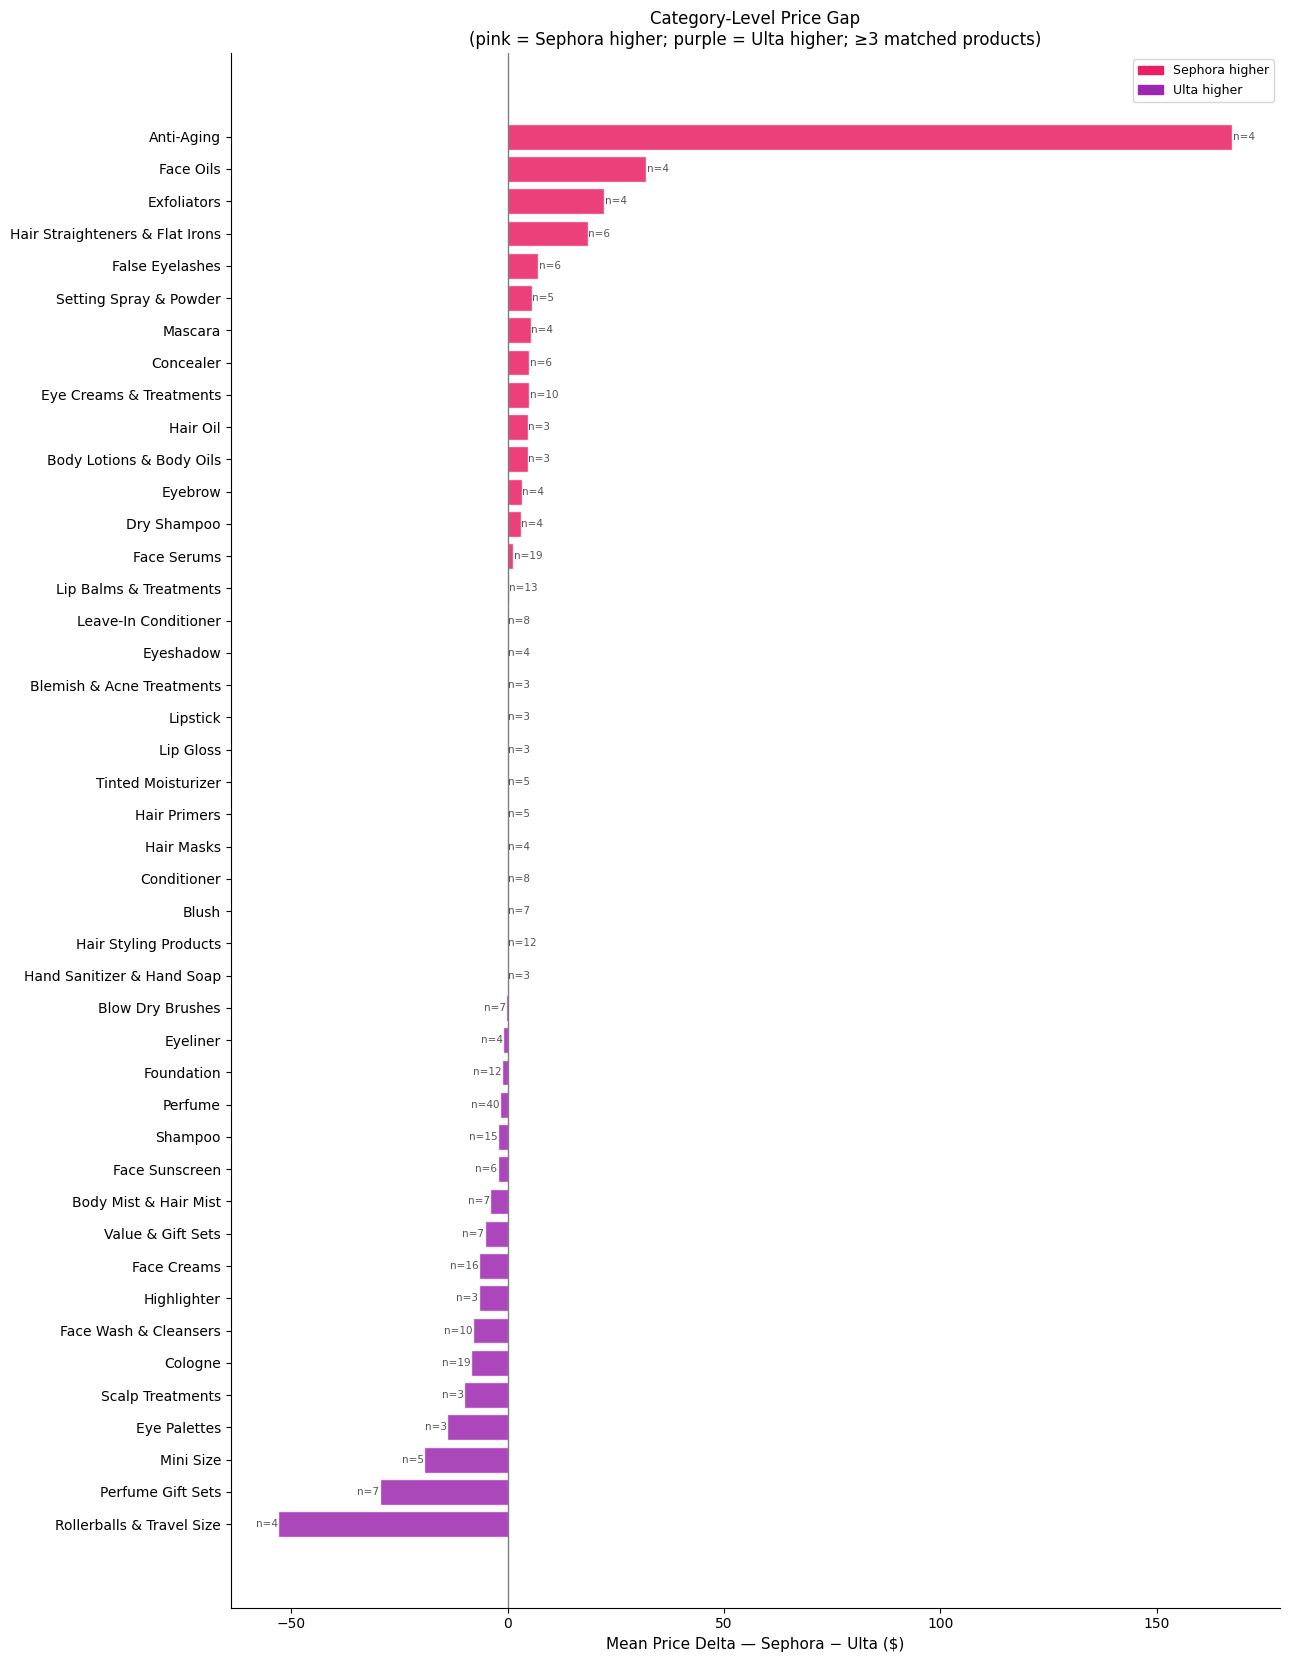

In [4]:
# Add category from sephora side
cross_cat = cross.merge(
    sephora_df[["product_id", "category"]].rename(
        columns={"product_id": "sephora_product_id", "category": "s_category"}
    ),
    on="sephora_product_id", how="left"
)

cat_price = (
    cross_cat
    .groupby("s_category")
    .agg(
        n               = ("sephora_product_id", "count"),
        mean_delta      = ("price_delta", "mean"),
        median_delta    = ("price_delta", "median"),
        pct_seph_higher = ("price_delta", lambda x: (x > 1).mean()),
        pct_parity      = ("price_parity", "mean"),
        pct_ulta_higher = ("price_delta", lambda x: (x < -1).mean()),
    )
    .query("n >= 3")
    .sort_values("mean_delta")
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, max(6, len(cat_price) * 0.38)))
bar_colors = [SEPHORA_COLOR if v > 0 else ULTA_COLOR for v in cat_price["mean_delta"]]
bars = ax.barh(cat_price["s_category"], cat_price["mean_delta"],
               color=bar_colors, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, cat_price.itertuples()):
    ax.text(
        bar.get_width() + (0.1 if bar.get_width() >= 0 else -0.1),
        bar.get_y() + bar.get_height() / 2,
        f"n={row.n}", va="center",
        ha="left" if bar.get_width() >= 0 else "right",
        fontsize=7.5, color="#555"
    )
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("Mean Price Delta — Sephora − Ulta ($)", fontsize=11)
ax.set_title("Category-Level Price Gap\n"
             "(pink = Sephora higher; purple = Ulta higher; ≥3 matched products)",
             fontsize=12)
ax.legend(handles=[
    mpatches.Patch(color=SEPHORA_COLOR, label="Sephora higher"),
    mpatches.Patch(color=ULTA_COLOR,    label="Ulta higher"),
], fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_category_price_gap.png",
            dpi=150, bbox_inches="tight")
plt.show()

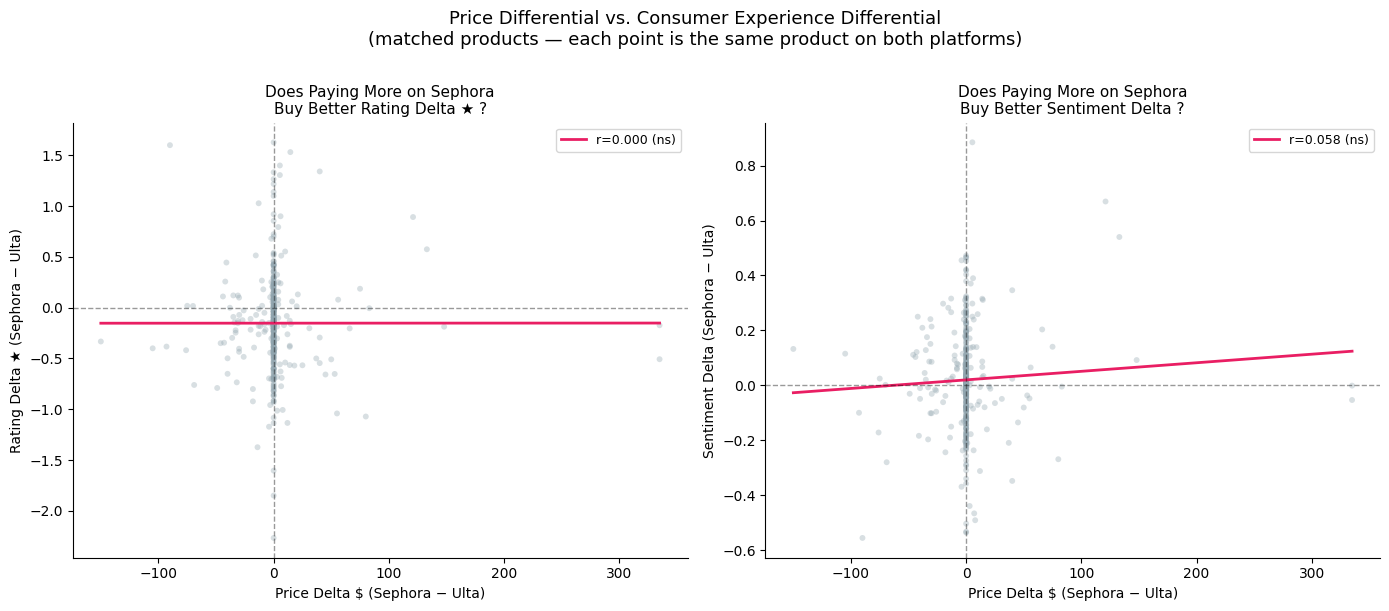

In [5]:
# Does paying more on Sephora buy better ratings or sentiment?

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_col, y_label in [
    (axes[0], "rating_delta",    "Rating Delta ★ (Sephora − Ulta)"),
    (axes[1], "sentiment_delta", "Sentiment Delta (Sephora − Ulta)"),
]:
    if y_col not in cross.columns:
        ax.text(0.5, 0.5, f"{y_col} not available",
                ha="center", va="center", transform=ax.transAxes)
        continue

    plot_sub = cross[["price_delta", y_col]].dropna()
    ax.scatter(plot_sub["price_delta"], plot_sub[y_col],
               alpha=0.35, s=18, color=NEUTRAL, edgecolors="none")

    # Regression
    if len(plot_sub) > 5:
        m, b, r, pv, _ = stats.linregress(plot_sub["price_delta"], plot_sub[y_col])
        xline = np.linspace(plot_sub["price_delta"].min(),
                            plot_sub["price_delta"].max(), 100)
        sig = "***" if pv < 0.001 else "**" if pv < 0.01 else \
              "*" if pv < 0.05 else "ns"
        ax.plot(xline, m * xline + b, color=SEPHORA_COLOR, lw=2,
                label=f"r={r:.3f} ({sig})")

    ax.axvline(0, color="black", lw=1, ls="--", alpha=0.4)
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.4)
    ax.set_xlabel("Price Delta $ (Sephora − Ulta)", fontsize=10)
    ax.set_ylabel(y_label, fontsize=10)
    ax.set_title(f"Does Paying More on Sephora\nBuy Better {y_label.split('(')[0]}?",
                 fontsize=11)
    ax.legend(fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Price Differential vs. Consumer Experience Differential\n"
             "(matched products — each point is the same product on both platforms)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_price_vs_experience_delta.png",
            dpi=150, bbox_inches="tight")
plt.show()

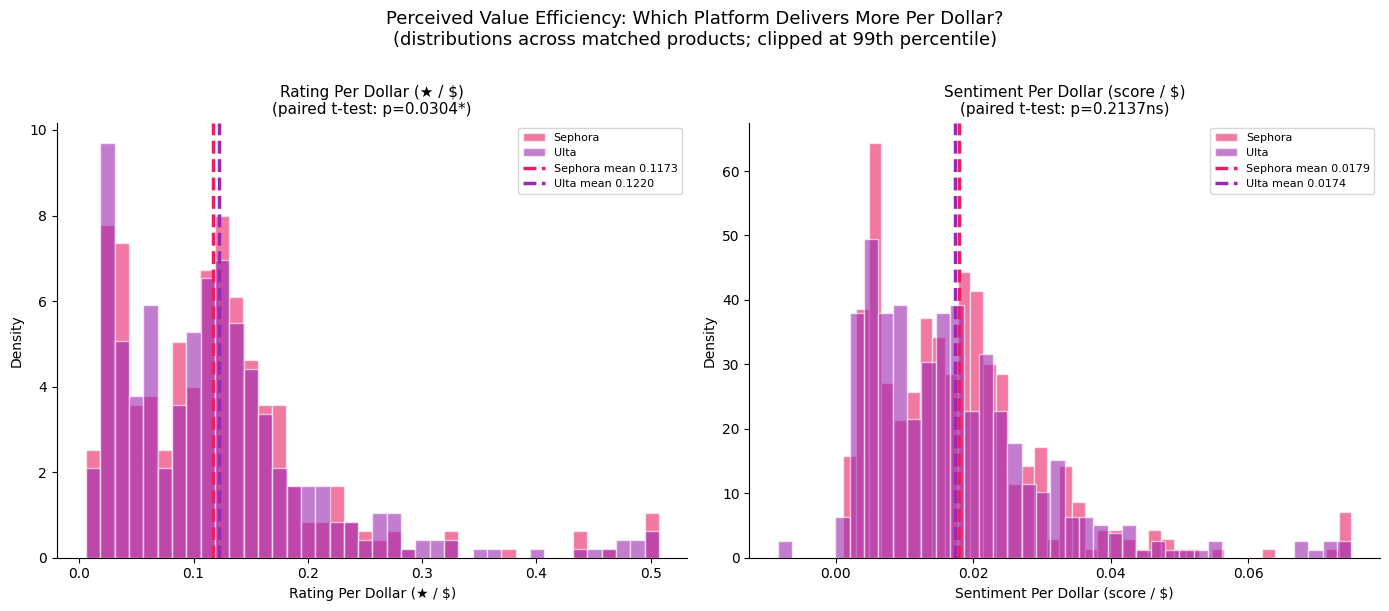

In [6]:
# rating per dollar and sentiment per dollar for each platform

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, metric, label in [
    (axes[0], "rating_per_dollar",    "Rating Per Dollar (★ / $)"),
    (axes[1], "sentiment_per_dollar", "Sentiment Per Dollar (score / $)"),
]:
    s_col = f"sephora_{metric}"
    u_col = f"ulta_{metric}"
    if s_col not in cross.columns or u_col not in cross.columns:
        ax.text(0.5, 0.5, f"{metric} not available",
                ha="center", va="center", transform=ax.transAxes)
        continue

    s_vals = cross[s_col].replace([np.inf, -np.inf], np.nan).dropna()
    u_vals = cross[u_col].replace([np.inf, -np.inf], np.nan).dropna()

    # Clip extreme outliers for display (< $2 products)
    clip_pct = 0.99
    clip_val = max(s_vals.quantile(clip_pct), u_vals.quantile(clip_pct))
    s_plot   = s_vals.clip(upper=clip_val)
    u_plot   = u_vals.clip(upper=clip_val)

    ax.hist(s_plot, bins=40, alpha=0.6, color=SEPHORA_COLOR, label="Sephora",
            edgecolor="white", density=True)
    ax.hist(u_plot, bins=40, alpha=0.6, color=ULTA_COLOR,    label="Ulta",
            edgecolor="white", density=True)
    ax.axvline(s_plot.mean(), color=SEPHORA_COLOR, lw=2.5, ls="--",
               label=f"Sephora mean {s_plot.mean():.4f}")
    ax.axvline(u_plot.mean(), color=ULTA_COLOR,    lw=2.5, ls="--",
               label=f"Ulta mean {u_plot.mean():.4f}")

    # Paired t-test on matched-pair efficiency difference
    paired = cross[[s_col, u_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(paired) > 5:
        t, pv = stats.ttest_rel(paired[s_col], paired[u_col])
        sig = "***" if pv < 0.001 else "**" if pv < 0.01 else \
              "*" if pv < 0.05 else "ns"
        ax.set_title(f"{label}\n(paired t-test: p={pv:.4f}{sig})", fontsize=11)
    else:
        ax.set_title(label, fontsize=11)

    ax.set_xlabel(label, fontsize=10)
    ax.set_ylabel("Density", fontsize=10)
    ax.legend(fontsize=8)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("Perceived Value Efficiency: Which Platform Delivers More Per Dollar?\n"
             "(distributions across matched products; clipped at 99th percentile)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_value_efficiency.png",
            dpi=150, bbox_inches="tight")
plt.show()

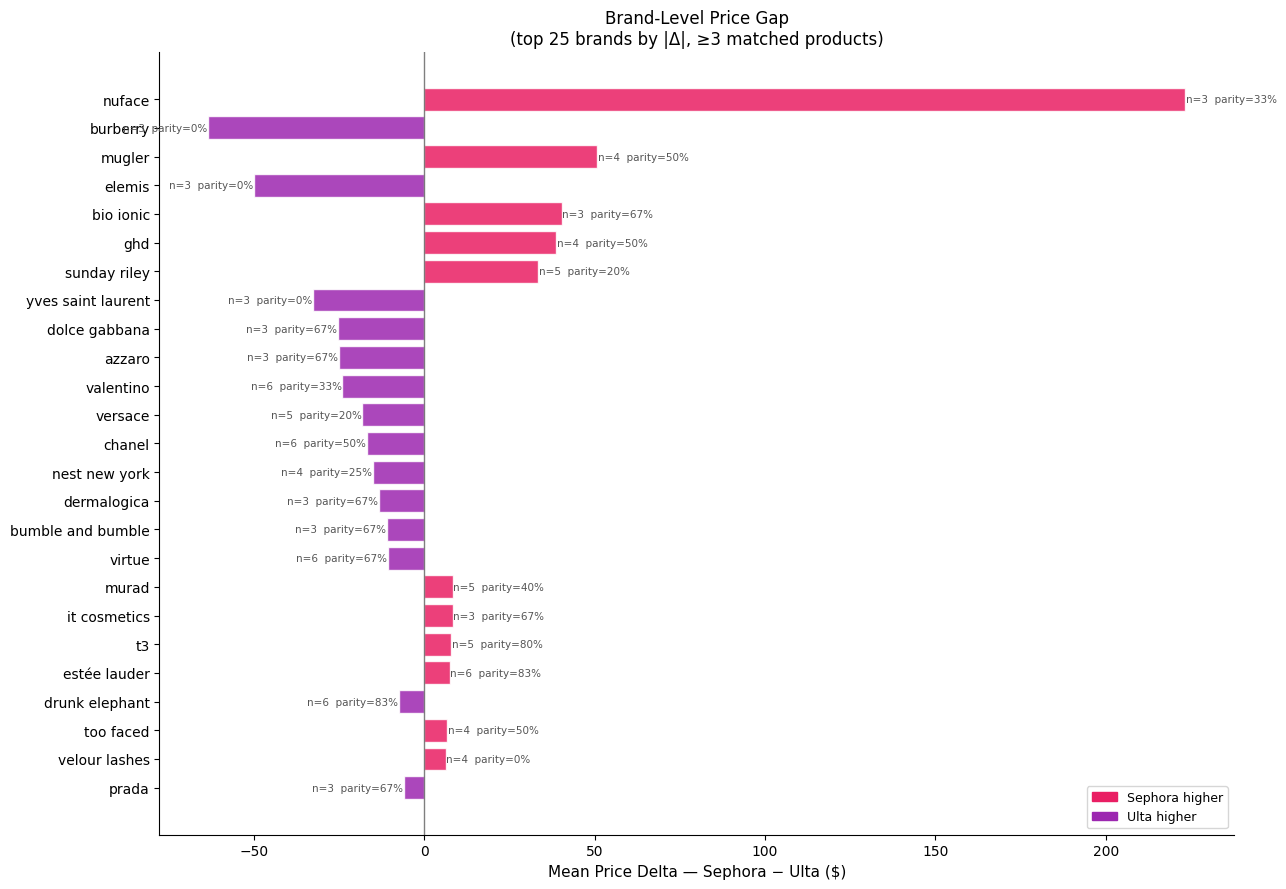

In [7]:
brand_price = (
    cross
    .groupby("sephora_brand_normalized")
    .agg(
        n               = ("sephora_product_id", "count"),
        mean_price_s    = ("sephora_price",  "mean"),
        mean_price_u    = ("ulta_price",     "mean"),
        mean_delta      = ("price_delta",    "mean"),
        pct_seph_higher = ("price_delta",    lambda x: (x > 1).mean()),
        pct_parity      = ("price_parity",   "mean"),
    )
    .reset_index()
    .query("n >= 3")
    .assign(abs_delta=lambda df: df["mean_delta"].abs())
    .sort_values("abs_delta")
    .tail(25)
)

fig, ax = plt.subplots(figsize=(13, 9))
bar_colors = [SEPHORA_COLOR if v > 0 else ULTA_COLOR
              for v in brand_price["mean_delta"]]
bars = ax.barh(brand_price["sephora_brand_normalized"],
               brand_price["mean_delta"],
               color=bar_colors, alpha=0.85, edgecolor="white")
for bar, row in zip(bars, brand_price.itertuples()):
    parity_txt = f"parity={row.pct_parity:.0%}"
    ax.text(
        bar.get_width() + (0.2 if bar.get_width() >= 0 else -0.2),
        bar.get_y() + bar.get_height() / 2,
        f"n={row.n}  {parity_txt}", va="center",
        ha="left" if bar.get_width() >= 0 else "right",
        fontsize=7.5, color="#555"
    )
ax.axvline(0, color="black", lw=1, alpha=0.5)
ax.set_xlabel("Mean Price Delta — Sephora − Ulta ($)", fontsize=11)
ax.set_title("Brand-Level Price Gap\n(top 25 brands by |Δ|, ≥3 matched products)",
             fontsize=12)
ax.legend(handles=[
    mpatches.Patch(color=SEPHORA_COLOR, label="Sephora higher"),
    mpatches.Patch(color=ULTA_COLOR,    label="Ulta higher"),
], fontsize=9, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_brand_price_gap.png",
            dpi=150, bbox_inches="tight")
plt.show()

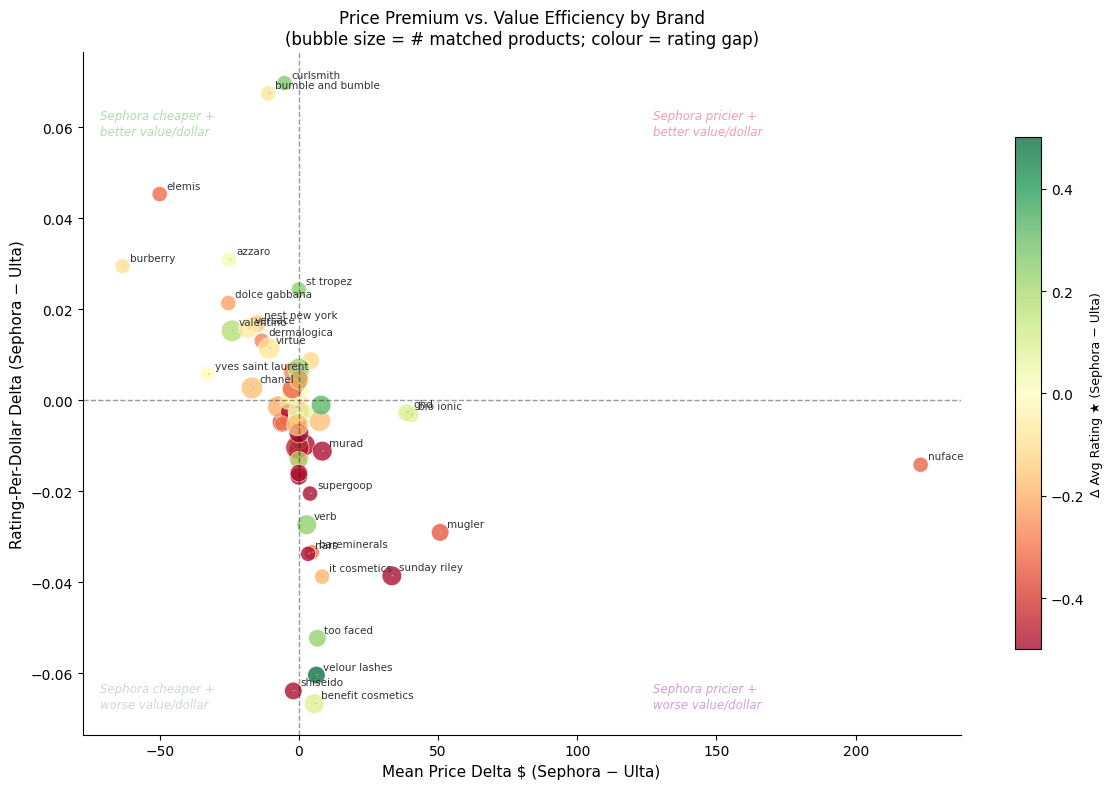

In [8]:
# Do brands that cost more on Sephora also deliver better value per dollar there?

brand_eff = (
    cross
    .groupby("sephora_brand_normalized")
    .agg(
        n                    = ("sephora_product_id", "count"),
        mean_price_delta     = ("price_delta", "mean"),
        mean_rating_delta    = ("rating_delta",    "mean") if "rating_delta"    in cross.columns else ("sephora_price", lambda x: np.nan),
        mean_sentiment_delta = ("sentiment_delta", "mean") if "sentiment_delta" in cross.columns else ("sephora_price", lambda x: np.nan),
        sephora_rpd          = ("sephora_rating_per_dollar",   "mean"),
        ulta_rpd             = ("ulta_rating_per_dollar",      "mean"),
    )
    .reset_index()
    .query("n >= 3")
    .dropna(subset=["mean_price_delta", "sephora_rpd", "ulta_rpd"])
)
brand_eff["rpd_delta"] = brand_eff["sephora_rpd"] - brand_eff["ulta_rpd"]

if len(brand_eff) > 0:
    fig, ax = plt.subplots(figsize=(12, 8))
    scatter = ax.scatter(
        brand_eff["mean_price_delta"],
        brand_eff["rpd_delta"],
        s=brand_eff["n"] * 40,
        c=brand_eff["mean_rating_delta"] if "rating_delta" in cross.columns else "#888",
        cmap="RdYlGn",
        alpha=0.75, edgecolors="white", linewidths=0.5,
        vmin=-0.5, vmax=0.5,
    )
    if "rating_delta" in cross.columns:
        cbar = plt.colorbar(scatter, ax=ax, shrink=0.75)
        cbar.set_label("Δ Avg Rating ★ (Sephora − Ulta)", fontsize=9)

    ax.axvline(0, color="black", lw=1, ls="--", alpha=0.4)
    ax.axhline(0, color="black", lw=1, ls="--", alpha=0.4)

    # Quadrant annotations
    q_style = dict(fontsize=8.5, alpha=0.45, style="italic")
    ax.text(0.02, 0.88, "Sephora cheaper +\nbetter value/dollar",
            transform=ax.transAxes, color=PARITY_COLOR, **q_style)
    ax.text(0.65, 0.88, "Sephora pricier +\nbetter value/dollar",
            transform=ax.transAxes, color=SEPHORA_COLOR, **q_style)
    ax.text(0.02, 0.04, "Sephora cheaper +\nworse value/dollar",
            transform=ax.transAxes, color=NEUTRAL, **q_style)
    ax.text(0.65, 0.04, "Sephora pricier +\nworse value/dollar",
            transform=ax.transAxes, color=ULTA_COLOR, **q_style)

    # Label outliers
    thr_x = brand_eff["mean_price_delta"].abs().quantile(0.75)
    thr_y = brand_eff["rpd_delta"].abs().quantile(0.75)
    for _, row in brand_eff[
        (brand_eff["mean_price_delta"].abs() > thr_x) |
        (brand_eff["rpd_delta"].abs()        > thr_y)
    ].iterrows():
        ax.annotate(row["sephora_brand_normalized"],
                    xy=(row["mean_price_delta"], row["rpd_delta"]),
                    xytext=(5, 4), textcoords="offset points",
                    fontsize=7.5, color="#333",
                    arrowprops=dict(arrowstyle="-", color="#bbb", lw=0.6))

    ax.set_xlabel("Mean Price Delta $ (Sephora − Ulta)", fontsize=11)
    ax.set_ylabel("Rating-Per-Dollar Delta (Sephora − Ulta)", fontsize=11)
    ax.set_title("Price Premium vs. Value Efficiency by Brand\n"
                 "(bubble size = # matched products; colour = rating gap)",
                 fontsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    plt.tight_layout()
    plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_price_vs_value_scatter.png",
                dpi=150, bbox_inches="tight")
    plt.show()

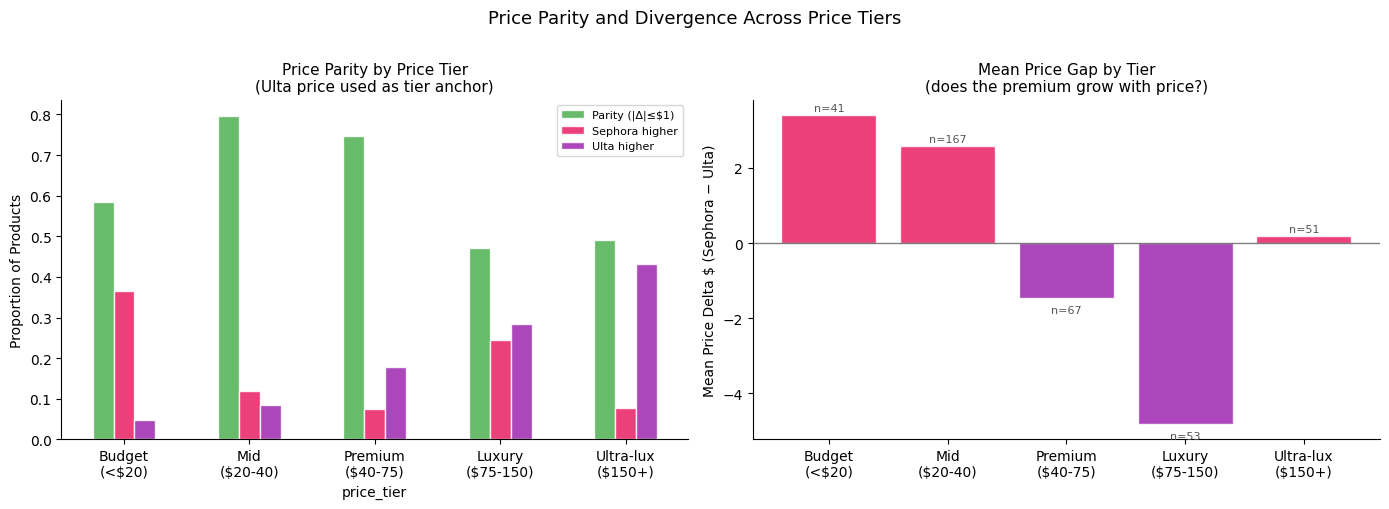

In [9]:
# Does parity hold differently at budget vs. luxury price points?

cross["price_tier"] = pd.cut(
    cross["ulta_price"],
    bins=[0, 20, 40, 75, 150, np.inf],
    labels=["Budget\n(<$20)", "Mid\n($20-40)", "Premium\n($40-75)",
            "Luxury\n($75-150)", "Ultra-lux\n($150+)"]
)

tier_stats = (
    cross.groupby("price_tier", observed=True)
    .agg(
        n               = ("sephora_product_id", "count"),
        mean_delta      = ("price_delta",    "mean"),
        pct_parity      = ("price_parity",   "mean"),
        pct_seph_higher = ("price_delta",    lambda x: (x > 1).mean()),
        pct_ulta_higher = ("price_delta",    lambda x: (x < -1).mean()),
        mean_price_u    = ("ulta_price",     "mean"),
        mean_price_s    = ("sephora_price",  "mean"),
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: parity rate by price tier
tier_counts = tier_stats[["price_tier", "pct_parity",
                            "pct_seph_higher", "pct_ulta_higher"]].set_index("price_tier")
tier_counts.plot(kind="bar", ax=axes[0],
                 color=[PARITY_COLOR, SEPHORA_COLOR, ULTA_COLOR],
                 alpha=0.85, edgecolor="white", rot=0)
axes[0].set_ylabel("Proportion of Products", fontsize=10)
axes[0].set_title("Price Parity by Price Tier\n"
                  "(Ulta price used as tier anchor)", fontsize=11)
axes[0].legend(["Parity (|Δ|≤$1)", "Sephora higher", "Ulta higher"],
               fontsize=8, loc="upper right")
axes[0].spines[["top", "right"]].set_visible(False)

# Panel 2: mean delta by price tier
bars = axes[1].bar(tier_stats["price_tier"].astype(str),
                   tier_stats["mean_delta"],
                   color=[SEPHORA_COLOR if v > 0 else ULTA_COLOR
                          for v in tier_stats["mean_delta"]],
                   alpha=0.85, edgecolor="white")
for bar, row in zip(bars, tier_stats.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + (0.1 if bar.get_height() >= 0 else -0.4),
                 f"n={row.n}", ha="center", fontsize=8, color="#555")
axes[1].axhline(0, color="black", lw=1, alpha=0.5)
axes[1].set_ylabel("Mean Price Delta $ (Sephora − Ulta)", fontsize=10)
axes[1].set_title("Mean Price Gap by Tier\n(does the premium grow with price?)",
                  fontsize=11)
axes[1].spines[["top", "right"]].set_visible(False)

fig.suptitle("Price Parity and Divergence Across Price Tiers",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(PROJECT_ROOT / "notebooks/joint/outputs" / "2.4_price_tier_analysis.png",
            dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("  2.4  PRICE CONSISTENCY & PERCEIVED VALUE — SUMMARY")

arr = cross["price_delta"].dropna().values
t, p = stats.ttest_1samp(arr, 0)
sig  = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
print(f"\nPrice delta (Sephora − Ulta) across {len(arr):,} matched products:")
print(f"  Mean          : ${arr.mean():+.2f}")
print(f"  Median        : ${np.median(arr):+.2f}")
print(f"  Std           : ${arr.std():.2f}")
print(f"  Sephora higher: {(arr > 1).sum():,}  ({(arr > 1).mean():.1%})")
print(f"  Ulta higher   : {(arr < -1).sum():,}  ({(arr < -1).mean():.1%})")
print(f"  Parity |Δ|≤$1 : {(np.abs(arr) <= 1).sum():,}  ({(np.abs(arr) <= 1).mean():.1%})")
print(f"  t-test vs 0   : t={t:.3f}, p={p:.4f} ({sig})")

print("\nPrice gap by tier:")
for _, row in tier_stats.iterrows():
    print(f"  {str(row['price_tier']):<20} n={row['n']:>3}  "
          f"mean_delta=${row['mean_delta']:+.2f}  "
          f"parity={row['pct_parity']:.0%}")

# Correlation: price delta vs rating delta
if "rating_delta" in cross.columns:
    sub = cross[["price_delta", "rating_delta"]].dropna()
    r, pv = stats.pearsonr(sub["price_delta"], sub["rating_delta"])
    sig2  = "***" if pv < 0.001 else "**" if pv < 0.01 else \
            "*" if pv < 0.05 else "ns"
    print(f"\nCorrelation: price delta × rating delta    "
          f"r={r:.4f}, p={pv:.4f} ({sig2})")

if "sentiment_delta" in cross.columns:
    sub = cross[["price_delta", "sentiment_delta"]].dropna()
    r, pv = stats.pearsonr(sub["price_delta"], sub["sentiment_delta"])
    sig2  = "***" if pv < 0.001 else "**" if pv < 0.01 else \
            "*" if pv < 0.05 else "ns"
    print(f"Correlation: price delta × sentiment delta "
          f"r={r:.4f}, p={pv:.4f} ({sig2})")

# Value efficiency summary
for metric, label in [("rating_per_dollar", "Rating/dollar"),
                       ("sentiment_per_dollar", "Sentiment/dollar")]:
    s_col, u_col = f"sephora_{metric}", f"ulta_{metric}"
    if s_col not in cross.columns:
        continue
    paired = cross[[s_col, u_col]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(paired) < 5:
        continue
    t, pv = stats.ttest_rel(paired[s_col], paired[u_col])
    sig2   = "***" if pv < 0.001 else "**" if pv < 0.01 else \
             "*" if pv < 0.05 else "ns"
    winner = "Sephora" if paired[s_col].mean() > paired[u_col].mean() else "Ulta"
    print(f"\n{label}  — {winner} delivers more per dollar  "
          f"(Sephora={paired[s_col].mean():.5f}, "
          f"Ulta={paired[u_col].mean():.5f}, "
          f"p={pv:.4f}{sig2})")

  2.4  PRICE CONSISTENCY & PERCEIVED VALUE — SUMMARY

Price delta (Sephora − Ulta) across 379 matched products:
  Mean          : $+0.60
  Median        : $+0.00
  Std           : $33.89
  Sephora higher: 57  (15.0%)
  Ulta higher   : 65  (17.2%)
  Parity |Δ|≤$1 : 257  (67.8%)
  t-test vs 0   : t=0.346, p=0.7293 (ns)

Price gap by tier:
  Budget
(<$20)        n= 41  mean_delta=$+3.40  parity=59%
  Mid
($20-40)         n=167  mean_delta=$+2.59  parity=80%
  Premium
($40-75)     n= 67  mean_delta=$-1.46  parity=75%
  Luxury
($75-150)     n= 53  mean_delta=$-4.81  parity=47%
  Ultra-lux
($150+)    n= 51  mean_delta=$+0.20  parity=49%

Correlation: price delta × rating delta    r=0.0002, p=0.9967 (ns)
Correlation: price delta × sentiment delta r=0.0581, p=0.2594 (ns)

Rating/dollar  — Ulta delivers more per dollar  (Sephora=0.11811, Ulta=0.12277, p=0.0304*)

Sentiment/dollar  — Sephora delivers more per dollar  (Sephora=0.01802, Ulta=0.01747, p=0.2137ns)


## Cross-Platform Price Consistency and Perceived Value

### Overall Price Architecture

The headline finding is that cross-platform price parity is the dominant operating state for matched products: 67.8% of the 379 matched pairs carry prices within $1 of each other, the median delta is exactly $0.00, and a t-test against zero is non-significant (t=0.35, p=0.73). The mean delta of +$0.60 is driven by a small number of outliers in both directions — the standard deviation of $33.93 against a mean of $0.60 confirms that the distribution is sharply concentrated at zero with heavy tails rather than shifted. The Sephora vs. Ulta price scatter reinforces this, with an r=0.903 fit line running almost exactly along the perfect parity diagonal across the full price range from budget to ultra-luxury. For the large majority of cross-listed products, price is a constant rather than a variable in the cross-channel consumer experience.

The 32.2% of products that do diverge split nearly evenly: 15.0% Sephora-higher and 17.2% Ulta-higher. There is no systematic platform premium in either direction at the aggregate level, meaning that when brands do deviate from parity, they do so in both directions at roughly equal rates and the deviations cancel out in the mean.

### Price Gap by Price Tier

The tier-level analysis reveals that the aggregate parity result conceals a meaningful price structure that varies systematically by price point. Budget and mid-tier products show small Sephora premiums on average — $3.40 at budget and $2.59 at mid — with parity rates of 59% and 80% respectively. These small Sephora premiums at accessible price points are consistent with Sephora's service and curation overhead being partially passed through on lower-priced products where the absolute premium is small relative to the product price.

The pattern reverses at premium and luxury price tiers. Premium products ($40–75) show a mean delta of −$1.46 (Ulta higher on average) and the luxury tier ($75–150) shows the largest absolute gap in the analysis at −$4.81 (Ulta higher), with parity falling to 47% — meaning more than half of luxury-tier matched products carry a price difference. Ultra-luxury ($150+) returns close to parity at $0.20 mean delta and 49% parity rate. The luxury tier inversion — where Ulta prices are systematically higher than Sephora for the same product — is the most counterintuitive finding in the price analysis and warrants specific explanation. Luxury fragrance and prestige skincare at the $75–150 tier include brands like Valentino, Versace, Chanel, and Dolce Gabbana whose Ulta fragrance pricing reflects that channel's positioning of designer fragrance as a premium category anchor, sometimes priced above Sephora's equivalent listings. Sephora's curation model in this tier may also involve more active negotiation of competitive pricing as part of brand partnership terms.

### Category-Level Price Gaps

The category chart surfaces the specific product types driving the brand-level and tier-level patterns. Anti-Aging shows by far the largest Sephora premium at the category level — approximately $170 mean delta across four matched products — driven by the presence of high-end anti-aging devices and treatments in the matched set where Sephora commands substantial premiums. Face Oils, Exfoliators, and Hair Straighteners and Flat Irons also show meaningful Sephora premiums, all categories where Sephora's prestige positioning or professional tool curation supports higher pricing.

The Ulta-higher categories cluster in fragrance and accessories: Rollerballs and Travel Size, Perfume Gift Sets, Mini Size, Eye Palettes, Scalp Treatments, Cologne, and Face Wash and Cleansers all show negative deltas. The fragrance subcategory pattern — both Cologne and Perfume Gift Sets showing Ulta premiums while standard Perfume shows near-zero delta — suggests that Ulta's fragrance accessory and gifting categories carry systematic Ulta premiums, possibly reflecting Ulta's stronger position in fragrance gifting relative to Sephora's focus on individual fragrance discovery. The largest Ulta-higher category by absolute magnitude is Rollerballs and Travel Size (approximately −$55 mean delta), though this likely reflects a small number of high-value travel kits in the matched set rather than a category-wide structural premium.

### Brand-Level Price Divergence

NuFACE is the most extreme brand-level price outlier with a mean Sephora premium of approximately $220 and a parity rate of only 33% — driven by NuFACE's facial device lineup where Sephora appears to price the same devices substantially above Ulta's listing prices. This is the only brand in the top-25 divergence list with a gap of this magnitude, and it reflects the device and tool category's less rigid price-parity conventions compared to consumable beauty products. Mugler, Bio Ionic, GHD, Sunday Riley, and T3 also show meaningful Sephora premiums, all in the device or prestige-accessible categories where Sephora's positioning supports modest premiums.

On the Ulta-higher side, Burberry and Elemis both show 0% parity rates — every matched product for these brands has a higher Ulta price — alongside Yves Saint Laurent, Dolce Gabbana, Azzaro, and Valentino, all luxury fragrance and fashion house brands whose fragrance portfolios are priced above Sephora equivalents at Ulta. The fragrance concentration in the Ulta-higher brand list is consistent with the category-level cologne and perfume gift set findings: designer fragrance is the one category where Ulta systematically commands higher prices than Sephora on the same SKUs.

### Does Paying More on Sephora Buy Better Consumer Experience?

The price differential versus consumer experience differential scatters answer this directly: no. The correlation between price delta and rating delta is r=0.0002 (ns) — essentially zero — and between price delta and sentiment delta is r=0.058 (ns). Products priced higher on Sephora than on Ulta receive neither better ratings nor better sentiment reviews at Sephora relative to the same product at Ulta. The price premium carries no measurable consumer experience premium in either direction. This finding holds across the full range of observed price deltas, from products $100 cheaper on Sephora to products $300 more expensive, with the scatter showing no pattern in either outcome variable as price delta varies.

The implication is that whatever drives the rating and sentiment gaps documented in the previous section — platform evaluation culture, consumer expectations, community composition — it operates independently of price. Products are not rated lower at Sephora because consumers paid more and expected more; the rating differential is structurally determined by platform context regardless of whether the product costs the same, more, or less than at Ulta.

### Perceived Value Efficiency: Rating and Sentiment Per Dollar

The value efficiency analysis reframes the comparison as return on consumer expenditure rather than absolute experience levels. On rating per dollar, Ulta delivers marginally more: 0.1228 stars per dollar versus Sephora's 0.1173, a difference that is statistically significant at p=0.030. The magnitude is small — approximately half a hundredth of a star per dollar — and the distributions overlap almost entirely, but the direction is consistent and reaches significance across 379 paired observations. Since prices are largely at parity, this difference is primarily driven by Sephora's lower absolute ratings for the same products rather than Sephora charging more for equivalent satisfaction.

On sentiment per dollar, Sephora delivers marginally more (0.01802 vs. 0.01747 sentiment units per dollar) but the difference is not significant (p=0.214). The two efficiency metrics therefore point in opposite directions and only one reaches significance, which is the appropriate null result given the platform-level baseline divergence between numerical ratings and written sentiment established earlier. Consumers spending the same amount at either platform receive statistically equivalent sentiment value, but marginally higher numerical rating value at Ulta — a consequence of Ulta's systematically more generous star rating culture rather than a genuine quality or satisfaction difference.